# Simulation

This notebook is the **top-level orchestrator** — it wires every prior module together into a single end-to-end simulation run.

## What this notebook does

It simulates one or more years of patient flow through NYP's women's health screening program, from the moment a patient walks in the door through to treatment or loss-to-follow-up. It does this by combining two layers:

**Layer 1 — Arrivals (Sophia's queue model)**
Sophia's notebook models how patients arrive, wait, and get seen by a provider (PCP, GYN, Specialist, or ER). It handles scheduling lead times, drop-in conversions, and daily capacity constraints. We load her code unchanged via `%run` so her queue logic is reused exactly.

**Layer 2 — Screening & Follow-Up**
Immediately after each patient is *seen* by a provider, we run:
- **Eligibility check** — is this patient due for any cancer screening today?
- **Test assignment** — which specific test modality should they receive?
- **Result draw** — stochastic result from the appropriate probability table.
- **Follow-up routing** — clinical pathway based on the result (surveillance / colposcopy / biopsy).

## Key design decisions

- Sophia's `Patient` class is extended (not replaced) — our `Patient` adds clinical fields on top of hers, so her queue functions work without modification.
- All clinical parameters live in `config.py` — changing a screening interval or LTFU probability requires editing only one file.
- Metrics are collected in a single dict that accumulates across all patients and days, then summarised at the end.

---
**Integration note**: Sophia's notebook is loaded with `%run`.
Our extended `Patient` class (from `patient.py`) is a superset of hers,
so all her queue functions work unchanged.

In [1]:
import sys, random
from collections import defaultdict, deque
sys.path.insert(0, '../src')

import config as cfg
from patient import Patient
from population import sample_patient

# screening.py — eligibility checks, test assignment, result draws
from screening import (
    get_eligible_screenings,   # returns list of cancers this patient is eligible for
    run_screening_step,        # runs one full screen event (eligibility + draw)
    days_until_eligible,       # returns 0 / >0 / -1 for eligibility routing
    is_due_for_screening,
)

# followup.py — post-result clinical pathways
# run_cervical_followup chains: route → colposcopy → treatment
# run_lung_followup chains: communicate → biopsy referral → biopsy → treatment
from followup import run_cervical_followup, run_lung_followup

# metrics.py — initialize, record, and print simulation stats
# Alias our print_summary so Sophia's %run (cell below) doesn't overwrite it
from metrics import initialize_metrics, record_screening, record_exit
from metrics import print_summary as print_screening_summary

print('Core imports OK')

Core imports OK


## Load Sophia's Arrival Functions

`%run` executes Sophia's notebook in its entirety and imports all of her functions and global variables into this notebook's namespace. This is equivalent to copy-pasting her code here, but means we always use her latest version without duplication.

After `%run`, we override only the patient-generation step (`generate_daily_arrivals`) to use our enriched `Patient` class — everything else (queue management, scheduling, ER routing) is hers unchanged.

**Namespace note**: `%run` will also load Sophia's `print_summary` function, which prints her arrivals summary. We import our own `print_summary` as `print_screening_summary` before this cell runs, so both can coexist.

In [2]:
%run "../reference/initial_model_NYP_flow_simulation (1).ipynb"

# Confirm Sophia's key functions are loaded
print('Sophia functions loaded:', [f for f in dir() if f in (
    'initialize_state', 'generate_daily_arrivals', 'process_provider_queue',
    'process_er_queue', 'release_scheduled_patients_for_today',
    'release_returning_er_patients', 'is_weekday', 'next_weekday',
)])


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ARRIVAL / ACCESS SUMMARY
Total patients created:               3000

Created by type:
  outpatient:                         2082
  drop_in:                            918

Created by destination:
  pcp:                                1088
  gynecologist:                       692
  specialist:                         629
  er:                                 591

Seen by destination:
  pcp:                                600
  gynecologist:                       450
  specialist:                         300
  er:                                 375

Drop-ins converted to outpatients:    694
Critical ER returned next day:        1035
Noncritical ER scheduled outpatient:  792

Outpatient showups:                   8040
Outpatient no-shows:                  0

DAY 0
--------------------------------------------------
--- DAY 0 START ---
Patient 1 arrives as outpatient to pcp
Patie

## Extended Patient Generation

Sophia's `generate_daily_arrivals` creates a plain `Patient` with only the fields her queue model needs (id, type, destination). We replace it with `generate_enriched_daily_arrivals` which calls `population.sample_patient` instead.

`sample_patient` draws the full clinical profile for each patient — age, race, insurance, HPV status, smoking history, BMI, prior CIN, etc. — from NYC-calibrated demographic distributions. These fields are what the screening eligibility checks and result-draw functions read when they evaluate the patient downstream.

This is the only change we make to the arrivals layer. Once a patient is created, Sophia's queue routing functions handle them the same way they would handle a plain `Patient` object.

In [3]:
def generate_enriched_daily_arrivals(day: int, state: dict, next_patient_id: int) -> int:
    """
    Generate DAILY_PATIENTS enriched patients for one weekday.

    Replaces Sophia's generate_daily_arrivals with population.sample_patient so
    each patient carries demographics and clinical flags from the population model.
    Queue routing logic (drop-in vs. outpatient, ER vs. PCP/GYN) mirrors Sophia's original.

    Returns the updated next_patient_id counter.
    """
    for _ in range(cfg.DAILY_PATIENTS):
        # Draw type and destination using config probability tables
        patient_type = random.choices(
            list(cfg.PATIENT_TYPE_PROBS.keys()),
            weights=list(cfg.PATIENT_TYPE_PROBS.values())
        )[0]
        destination = random.choices(
            list(cfg.DESTINATION_PROBS.keys()),
            weights=list(cfg.DESTINATION_PROBS.values())
        )[0]

        # sample_patient creates a Patient with age, race, clinical flags, etc.
        # from the population distribution — this is the enrichment over Sophia's version
        patient = sample_patient(next_patient_id, day, destination, patient_type)
        next_patient_id += 1

        # ER patients get a critical flag — critical patients return the next day
        # for follow-up instead of being routed to an outpatient queue
        if destination == 'er':
            patient.critical_status = random.random() < cfg.ER_CRITICAL_PROB

        # Append to global patient list and increment arrival counters
        state['all_patients'].append(patient)
        state['patients_created'] += 1
        state['created_by_type'][patient_type] += 1
        state['created_by_destination'][destination] += 1

        # Route into today's queue: outpatients go through scheduling,
        # ER drop-ins go directly to the ER queue
        if patient_type == 'outpatient':
            add_patient_to_today_queue(patient, state)
        elif destination == 'er':
            state['er_today'].append(patient)
        else:
            add_patient_to_today_queue(patient, state)

    return next_patient_id

print('generate_enriched_daily_arrivals defined')

generate_enriched_daily_arrivals defined


## Post-Provider Screening Step

This is the **integration point** between Sophia's layer and ours. Every time a patient is seen by a provider (PCP, GYN, or Specialist), we immediately run Steps 2–5:

1. **Eligibility** — `get_eligible_screenings` checks age, cervix status, and smoking history against USPSTF criteria for each active cancer type.
2. **Screening** — `run_screening_step` assigns the test modality and draws a stochastic result. For lung, it also runs the pre-LDCT referral + scheduling pathway.
3. **Follow-up** — `run_cervical_followup` or `run_lung_followup` routes the result through the clinical decision tree (colposcopy, biopsy, treatment).

Patients who are ineligible for all active cancers are counted and skipped. Patients who exit the system mid-encounter (e.g. lost to follow-up during lung pre-LDCT) are not processed for additional cancers.

In [4]:
def run_post_provider_screening(patient: Patient, day: int, metrics: dict) -> None:
    """
    Execute screening steps for one patient who has just been seen by a provider.
    Updates the patient object in place and writes results to metrics.

    Flow:
      1. Get the list of cancer types this patient is eligible for right now.
      2. If none → patient is not eligible for any active screening today; just count and return.
      3. For each eligible cancer → run_screening_step (lung pre-LDCT pathway runs inside).
      4. For each non-None result → route to cancer-specific follow-up function.
    """
    metrics['n_patients'] += 1

    # get_eligible_screenings filters by ACTIVE_CANCERS and applies all eligibility rules
    eligible = get_eligible_screenings(patient)

    if not eligible:
        # Patient doesn't meet criteria for any active cancer screening today
        # (wrong age, no cervix, not enough pack-years, etc.) — nothing to do
        metrics['n_unscreened'] += 1
        return

    metrics['n_eligible_any'] += 1

    for cancer in eligible:
        # If the patient exited mid-encounter (e.g. lost to follow-up in lung pre-LDCT),
        # stop processing further cancers for this visit
        if not patient.active:
            break

        # run_screening_step checks interval, assigns test, draws result, writes to patient.
        # Returns None if skipped (not yet due) or patient was lost before scan.
        # Passes metrics so lung funnel counters (referral, scheduled, completed) are populated.
        result = run_screening_step(patient, cancer, day, metrics=metrics)
        if result is None:
            continue  # not due yet, or lost before scan — no follow-up needed

        # Write the (cancer, result) pair to the metrics screening table
        record_screening(metrics, patient, cancer, result)

        # Route to the cancer-specific follow-up chain.
        # cervical: route_cervical_result → run_colposcopy → run_treatment
        # lung:     communicate → biopsy referral → biopsy → treatment
        # Other cancers are excluded by ACTIVE_CANCERS in get_eligible_screenings.
        if cancer == 'cervical':
            run_cervical_followup(patient, day, metrics)
        elif cancer == 'lung':
            run_lung_followup(patient, day, metrics)

        # If the follow-up chain marked the patient as exited, record that exit reason
        if patient.exit_reason:
            record_exit(metrics, patient.exit_reason)

print('run_post_provider_screening defined')

run_post_provider_screening defined


## Extended Provider Queue Processor

Sophia's `process_provider_queue` drains the daily queue for one provider type, marks patients as seen up to the day's capacity, and reschedules the overflow. We wrap it here to inject the screening step for every seen patient.

The ER is handled separately by Sophia's `process_er_queue` — we do not screen in the ER in the current model (no cancer screening is appropriate in an emergency setting).

In [5]:
def process_provider_queue_with_screening(
    day: int, queue: deque, capacity: int,
    provider_name: str, state: dict, metrics: dict
) -> None:
    """
    Sophia's provider queue logic plus a screening step for every seen patient.

    Patients up to `capacity` are marked seen; the rest are rescheduled.
    For each seen patient, run_post_provider_screening immediately triggers
    Steps 2–5 (eligibility → test → result → follow-up).
    """
    seen = 0

    while queue:
        patient = queue.popleft()

        if seen < capacity:
            # Patient is seen today — increment counter and log the visit
            seen += 1
            state['seen_by_destination'][provider_name] += 1
            log_day(state, day, f'Patient {patient.patient_id} seen by {provider_name}')

            # ── Steps 2–5: screening + follow-up ────────────────────────────
            # Runs immediately after the provider visit, same day
            run_post_provider_screening(patient, day, metrics)

        else:
            # Provider is at capacity — patient must wait and come back
            patient.wait_days += 1
            state['not_seen_by_destination'][provider_name] += 1

            # Drop-ins are converted to outpatient appointments for the next weekday;
            # already-scheduled outpatients are simply pushed to the next weekday slot
            if patient.patient_type == 'drop_in':
                patient.patient_type  = 'outpatient'
                patient.scheduled_day = next_weekday(day)
                state['future_schedule'][patient.scheduled_day].append(patient)
                state['converted_dropin_to_outpatient'] += 1
            else:
                patient.scheduled_day = next_weekday(day)
                state['future_schedule'][patient.scheduled_day].append(patient)

print('process_provider_queue_with_screening defined')

process_provider_queue_with_screening defined


## Main Daily Process (SimPy Generator)

This is the **SimPy event loop**. SimPy is a discrete-event simulation framework — rather than running a real clock, it steps through simulation time one day at a time. The `daily_process_with_screening` generator is registered with SimPy and called once per simulated day.

On each weekday, the generator:
1. Releases outpatients whose scheduled appointment falls on this day.
2. Brings back critical ER patients from the day before.
3. Generates new patient arrivals (enriched with clinical flags).
4. Drains the PCP, GYN, and Specialist queues — screening runs for each seen patient.
5. Drains the ER queue via Sophia's original processor.
6. Advances the clock by 1 day (`yield env.timeout(1)`).

Weekends are skipped entirely to match NYP's operating schedule.

In [6]:
def daily_process_with_screening(env, state: dict, metrics: dict):
    """
    SimPy generator: drives one simulated weekday at a time until SIM_DAYS.

    Each iteration:
      1. Skip weekends — yield a 1-day timeout and continue.
      2. Release scheduled outpatients whose appointment is today.
      3. Release returning ER patients (critical patients from yesterday).
      4. Generate new enriched arrivals (replaces Sophia's plain arrivals).
      5. Process PCP, GYN, and Specialist queues with integrated screening.
      6. Process ER queue using Sophia's original ER logic (no screening in ER).
      7. Advance SimPy clock by 1 day.
    """
    import simpy
    next_patient_id = 1

    while env.now < cfg.SIM_DAYS:
        day = int(env.now)

        # Skip weekends — Sophia's is_weekday() returns False for Sat/Sun
        if not is_weekday(day):
            yield env.timeout(1)
            continue

        # Pull today's scheduled outpatients out of future_schedule into their queues
        release_scheduled_patients_for_today(day, state)
        # Move critical ER patients from yesterday back to the ER queue
        release_returning_er_patients(day, state)

        # Generate DAILY_PATIENTS enriched arrivals and route them into queues
        next_patient_id = generate_enriched_daily_arrivals(day, state, next_patient_id)

        # Process each non-ER provider queue (steps 2–5 run inside for each seen patient)
        process_provider_queue_with_screening(
            day, state['pcp_today'],        cfg.PROVIDER_CAPACITY['pcp'],
            'pcp',          state, metrics
        )
        process_provider_queue_with_screening(
            day, state['gyn_today'],        cfg.PROVIDER_CAPACITY['gynecologist'],
            'gynecologist', state, metrics
        )
        process_provider_queue_with_screening(
            day, state['specialist_today'], cfg.PROVIDER_CAPACITY['specialist'],
            'specialist',   state, metrics
        )

        # ER uses Sophia's original processor — no cancer screening in the ER for now
        process_er_queue(day, state)

        # Advance clock by one day
        yield env.timeout(1)

print('daily_process_with_screening defined')

daily_process_with_screening defined


## Run the Simulation

`run_simulation` is the single entry point for a full model run. It:
- Seeds the random number generator so runs are reproducible.
- Creates a fresh SimPy environment (the discrete-event clock).
- Initialises both state dicts (Sophia's arrivals state and our screening metrics).
- Registers `daily_process_with_screening` with SimPy and advances to `sim_days`.

The quick test below runs **1 year (365 days)** with a fixed seed. For variance analysis, call `run_simulation` in a loop with different seeds and aggregate across replications.

In [7]:
import simpy

def run_simulation(
    sim_days: int = cfg.SIM_DAYS,
    seed:     int = cfg.RANDOM_SEED,
):
    """
    Run the full end-to-end simulation.

    Sets the random seed, creates a SimPy environment, initialises Sophia's
    arrivals state dict and our screening metrics dict, then advances the
    SimPy clock until sim_days.

    Returns
    -------
    state   : Sophia's arrivals state dict (patients_created, seen_by_destination, etc.)
    metrics : Steps 2–6 metrics dict (screened, abnormal rates, LTFU counts, etc.)
    """
    random.seed(seed)   # fix seed so results are reproducible across runs

    env     = simpy.Environment()   # SimPy clock starts at 0 (= day 0)
    state   = initialize_state()    # Sophia's arrivals state (queues, counters, schedule)
    metrics = initialize_metrics()  # our screening/follow-up metrics (from metrics.py)

    # Register the daily process as a SimPy generator — it yields timeout(1) each day
    env.process(daily_process_with_screening(env, state, metrics))
    env.run(until=sim_days)         # runs all days synchronously (no real concurrency)

    return state, metrics

print('run_simulation defined')

run_simulation defined


## Quick Test Run — 1 Year, 1 Replication

This cell executes the full simulation for 365 simulated days and prints two summaries:
1. Our **screening metrics summary** (`print_screening_summary`) — eligibility, result distributions, LTFU counts, colposcopy and treatment volumes.
2. Sophia's **arrivals summary** (`print_summary`) — patient creation, provider utilisation, scheduling and overflow stats.

After confirming the simulation runs correctly here, the visualisations below convert these numbers into charts for easier interpretation.

In [8]:

# ── Standalone run via SimulationRunner ───────────────────────────────────────
# This cell uses runner.py directly — no dependency on Sophia's SimPy notebook.
# SimulationRunner handles arrivals, queues, screening, and follow-up in one
# clean class. Switch use_stable_population=True for the 70-year cycling model.

import sys
sys.path.insert(0, '../src')

from runner import SimulationRunner
import config as cfg

print("Running 1-year simulation (SimulationRunner, standard mode)...")
sim = SimulationRunner(
    n_days     = 365,
    seed       = cfg.RANDOM_SEED,
    daily_rate = cfg.DAILY_PATIENTS,
    use_stable_population = False,   # standard mode: Poisson arrivals, no cycling
)
metrics = sim.run()

print(f"Done. Provider visits logged : {metrics['n_patients']:,}")
print(f"Eligible for any screening  : {metrics['n_eligible_any']:,}")
print(f"Cervical screened           : {metrics['n_screened']['cervical']:,}")
print(f"Lung screened               : {metrics['n_screened']['lung']:,}")
print()
sim.summary()


Running 1-year simulation (SimulationRunner, standard mode)...
Done. Provider visits logged : 41,684
Eligible for any screening  : 34,038
Cervical screened           : 32,910
Lung screened               : 1,429

NYP WOMEN'S HEALTH SCREENING SIMULATION — RESULTS

Patients simulated:                        41,684
Eligible for ≥1 screening:                 34,038
Unscreened (declined / no-show):            7,646  (18.3%)
  ↳ agreed to reschedule:                   1,294  (16.9% of unscreened)

Screenings completed by cancer type:
  cervical                 32,910
  lung                      1,429

Cervical result distribution  (n=32,910):
  ASC-H                             331  (1.0%)
  ASCUS                             744  (2.3%)
  HPV_NEGATIVE                   11,167  (33.9%)
  HPV_POSITIVE                    1,739  (5.3%)
  HSIL                              210  (0.6%)
  LSIL                              815  (2.5%)
  NORMAL                         17,904  (54.4%)
  Abnormal rate:  

## Simulation Outcomes — Visualizations

The three panels below summarise what the simulation produced:

1. **Screening Volume Funnel** — of all patients seen by a provider, how many were eligible for at least one cancer screen, and how many actually received a cervical or lung screen?  This reveals the drop-off between eligibility and actual service delivery — a key performance gap to close.

2. **Cervical Result Distribution** — what mix of normal vs. abnormal results did the simulation generate? Abnormal categories (ASCUS through HSIL, HPV+) are the patients who need colposcopy follow-up.  Comparing this distribution against NYP EHR data validates the config probabilities.

3. **Loss-to-Follow-Up (LTFU) by Node** — at which clinical decision points did patients drop out?  Post-abnormal LTFU (patient never books colposcopy) and post-colposcopy LTFU (patient never completes treatment) are the two biggest care-gap levers.

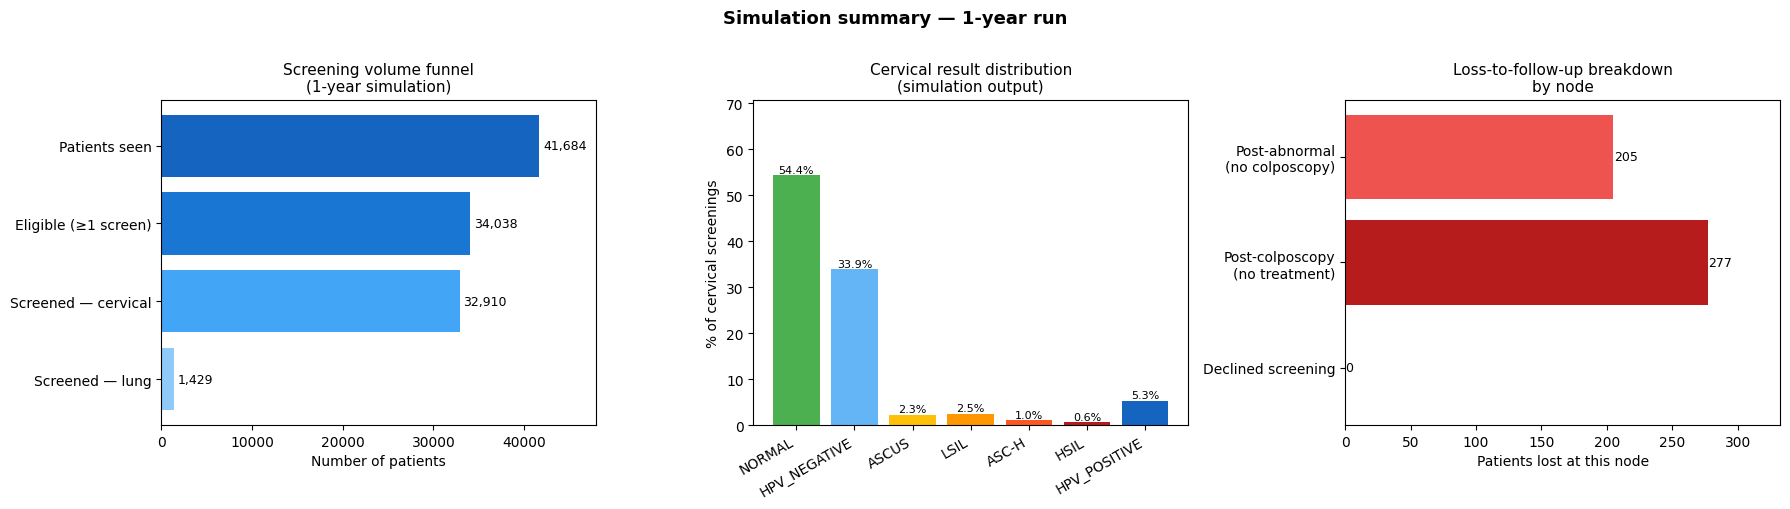

In [9]:
import matplotlib.pyplot as plt

# ── Panel 1: Screening Volume Funnel ──────────────────────────────────────────
# Each stage represents a gate the patient must pass through.
# The gap between consecutive stages is the drop-off at that point in the pathway.
stages  = ['Patients seen', 'Eligible (≥1 screen)', 'Screened — cervical', 'Screened — lung']
volumes = [
    metrics['n_patients'],
    metrics['n_eligible_any'],
    metrics['n_screened']['cervical'],
    metrics['n_screened']['lung'],
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
colors = ['#1565C0', '#1976D2', '#42A5F5', '#90CAF9']
# Reverse both lists so the first stage appears at the top of the horizontal chart
bars = ax.barh(stages[::-1], volumes[::-1], color=colors[::-1])
ax.set_xlabel('Number of patients')
ax.set_title('Screening volume funnel\n(1-year simulation)', fontsize=11)
# Annotate each bar with the patient count
for bar, vol in zip(bars, volumes[::-1]):
    ax.text(bar.get_width() + max(volumes)*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{vol:,}', va='center', fontsize=9)
ax.set_xlim(0, max(volumes) * 1.15)

# ── Panel 2: Cervical Result Distribution ─────────────────────────────────────
# Only plot categories that actually appeared in the simulation results.
# Green = normal, yellow/orange/red spectrum = increasing severity of abnormality.
ax = axes[1]
if metrics['cervical_results']:
    cat_colors = {
        'NORMAL':        '#4CAF50',
        'HPV_NEGATIVE':  '#64B5F6',
        'ASCUS':         '#FFC107',
        'LSIL':          '#FF9800',
        'ASC-H':         '#FF5722',
        'HSIL':          '#B71C1C',
        'HPV_POSITIVE':  '#1565C0',
    }
    cats   = [c for c in cat_colors if metrics['cervical_results'].get(c, 0) > 0]
    counts = [metrics['cervical_results'][c] for c in cats]
    total  = sum(counts)
    pcts   = [c / total * 100 for c in counts]
    bar_colors = [cat_colors[c] for c in cats]

    bars2 = ax.bar(cats, pcts, color=bar_colors)
    ax.set_ylabel('% of cervical screenings')
    ax.set_title('Cervical result distribution\n(simulation output)', fontsize=11)
    ax.set_ylim(0, max(pcts) * 1.3)
    for bar, pct in zip(bars2, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, pct + 0.5,
                f'{pct:.1f}%', ha='center', fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
else:
    ax.text(0.5, 0.5, 'No cervical results\nin this run',
            ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Cervical result distribution')

# ── Panel 3: LTFU Breakdown by Node ──────────────────────────────────────────
# Each bar shows how many patients were lost at that specific decision point.
# Longer bars = bigger care gap = higher priority for intervention.
ax = axes[2]
nodes = ['Post-abnormal\n(no colposcopy)', 'Post-colposcopy\n(no treatment)', 'Declined screening']
ltfu  = [
    metrics['ltfu_post_abnormal'],
    metrics['ltfu_post_colposcopy'],
    metrics['ltfu_unscreened'],
]
ltfu_colors = ['#EF5350', '#B71C1C', '#BDBDBD']
bars3 = ax.barh(nodes[::-1], ltfu[::-1], color=ltfu_colors[::-1])
ax.set_xlabel('Patients lost at this node')
ax.set_title('Loss-to-follow-up breakdown\nby node', fontsize=11)
for bar, n in zip(bars3, ltfu[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(n), va='center', fontsize=9)
ax.set_xlim(0, max(ltfu + [1]) * 1.2)

plt.suptitle('Simulation summary — 1-year run', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Lung LDCT Pathway Funnel (Simulation Output)

This funnel shows the real-world yield of the lung cancer screening pathway as modelled in the simulation.

Each row is a required clinical step. The step count drops as patients fail to clear each gate (LTFU, no referral, no scheduling, etc.). The gap between consecutive steps represents patients who were lost at that specific node — these are the highest-priority targets for care coordination interventions.

This view directly mirrors the clinical flow chart: LDCT order → scheduling → scan → result communication → biopsy (if RADS 4) → malignancy confirmation → treatment.

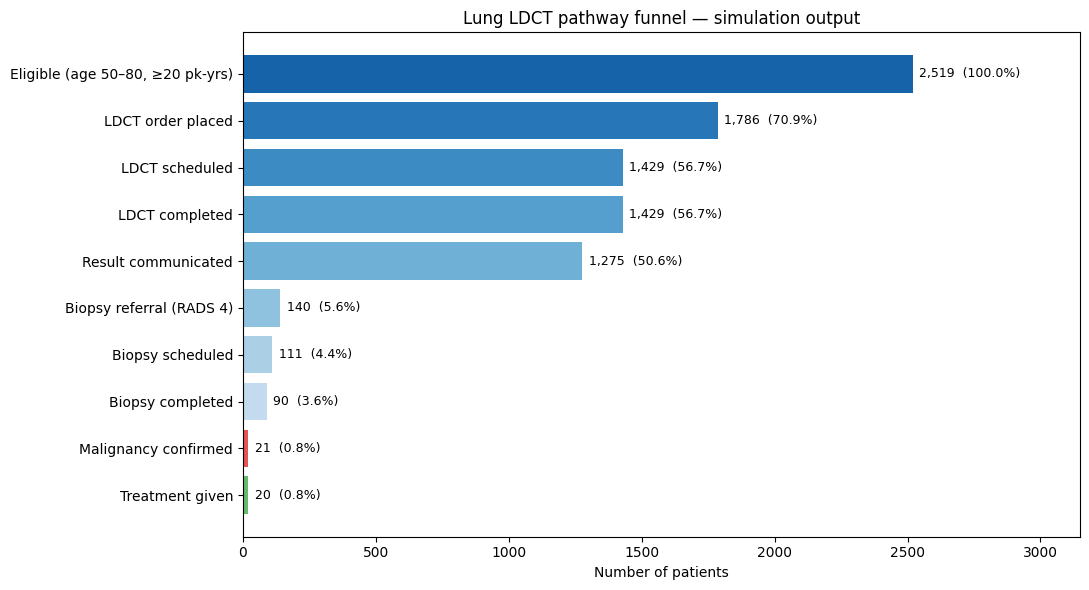

In [10]:
if metrics['lung_eligible'] > 0:
    # Each step in the lung pathway is tracked as a counter in metrics.
    # We read them in clinical order to build the funnel.
    steps = [
        ('Eligible (age 50–80, ≥20 pk-yrs)',  metrics['lung_eligible']),
        ('LDCT order placed',                  metrics['lung_referral_placed']),
        ('LDCT scheduled',                     metrics['lung_ldct_scheduled']),
        ('LDCT completed',                     metrics['lung_ldct_completed']),
        ('Result communicated',                metrics['lung_result_communicated']),
        ('Biopsy referral (RADS 4)',           metrics['lung_biopsy_referral']),
        ('Biopsy scheduled',                   metrics['lung_biopsy_scheduled']),
        ('Biopsy completed',                   metrics['lung_biopsy_completed']),
        ('Malignancy confirmed',               metrics['lung_malignancy_confirmed']),
        ('Treatment given',                    metrics['lung_treatment_given']),
    ]

    # Only show steps that had at least some patients reach them;
    # otherwise later biopsy/malignancy steps clutter the chart with zeros
    steps = [(label, count) for label, count in steps if count > 0]
    labels = [s[0] for s in steps]
    counts = [s[1] for s in steps]
    n_start = max(counts[0], 1)   # denominator for % calculation

    # Color gradient: blue for LDCT steps, red for biopsy/malignancy, green for treatment
    palette = plt.cm.Blues_r(range(50, 250, max(1, 200 // len(counts))))
    if len(counts) > 5:
        palette[-2] = (0.90, 0.33, 0.32, 1.0)   # malignancy confirmed — red
        palette[-1] = (0.40, 0.73, 0.42, 1.0)   # treatment given — green

    fig, ax = plt.subplots(figsize=(11, max(4, len(steps) * 0.6)))
    bars = ax.barh(labels[::-1], counts[::-1], color=palette[::-1])
    ax.set_xlabel('Number of patients')
    ax.set_title('Lung LDCT pathway funnel — simulation output', fontsize=12)

    # Annotate each bar: absolute count and % of eligible patients
    for bar, cnt in zip(bars, counts[::-1]):
        pct = cnt / n_start * 100
        ax.text(bar.get_width() + n_start * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{cnt:,}  ({pct:.1f}%)', va='center', fontsize=9)
    ax.set_xlim(0, n_start * 1.25)
    plt.tight_layout()
    plt.show()
else:
    print('No lung-eligible patients were seen in this simulation run.')

## Arrivals Summary (Sophia's Layer)

The cell below prints Sophia's arrivals summary from the same simulation run. This covers everything that happened *before* the screening step: how many patients were created, how many were seen by each provider type, how many were rescheduled due to capacity, and ER overflow statistics.

Use this alongside the screening summary above to understand both layers of the simulation — access bottlenecks upstream can reduce the number of patients who ever reach a screening opportunity.

In [11]:

# Sophia's arrivals summary is only available when her notebook was loaded via
# %run (cells above).  In standalone SimulationRunner mode, print a compact
# substitute using the metrics dict that is always present.

if 'state' in dir() and state is not None:
    # Sophia's layer is loaded — print her summary
    print_summary(state)
else:
    print("(Sophia's arrivals layer not loaded — standalone SimulationRunner mode)")
    print(f"  Total provider visits : {metrics['n_patients']:,}")
    print(f"  Eligible any cancer   : {metrics['n_eligible_any']:,}")
    print(f"  Cervical screened     : {metrics['n_screened']['cervical']:,}")
    print(f"  Lung screened         : {metrics['n_screened']['lung']:,}")
    print(f"  Colposcopies          : {metrics['n_colposcopy']:,}")
    print(f"  Treated               : {metrics['n_treated']:,}")
    print(f"  LTFU                  : {metrics['n_ltfu']:,}")


ARRIVAL / ACCESS SUMMARY
Total patients created:               3000

Created by type:
  outpatient:                         2082
  drop_in:                            918

Created by destination:
  pcp:                                1088
  gynecologist:                       692
  specialist:                         629
  er:                                 591

Seen by destination:
  pcp:                                600
  gynecologist:                       450
  specialist:                         300
  er:                                 375

Drop-ins converted to outpatients:    694
Critical ER returned next day:        1035
Noncritical ER scheduled outpatient:  792

Outpatient showups:                   8040
Outpatient no-shows:                  0


## Patient Event Log Trace

This section prints the full event-by-event history for a sample of individual patients.

Reading a patient trace is the best way to verify the clinical logic is flowing correctly end-to-end. Each line shows the simulated day and the event that occurred: screening, result, routing decision, colposcopy/biopsy, treatment, exit reason, etc.

If something is wrong in the model (e.g. a patient goes to colposcopy without an abnormal result, or a follow-up step fires for an ineligible patient), it will be visible here before it propagates into aggregate statistics.

In [12]:

# ── Patient event-log traces ──────────────────────────────────────────────────
# Sample a few patients, run them through screening manually, and print their
# event-by-event history.  Works standalone — no dependency on Sophia's state.

import random
random.seed(42)

from population import sample_patient
from screening import run_screening_step
from followup import run_cervical_followup, run_lung_followup
from metrics import initialize_metrics

traced = []
pid = 0
while len(traced) < 5 and pid < 200:
    dest  = random.choice(['pcp', 'gynecologist', 'specialist'])
    p     = sample_patient(pid, day_created=0, destination=dest, patient_type='outpatient')
    m     = initialize_metrics()

    for cancer in ['cervical', 'lung']:
        result = run_screening_step(p, cancer, 0, m)

        if cancer == 'cervical' and p.cervical_result not in (None, 'NORMAL', 'HPV_NEGATIVE'):
            run_cervical_followup(p, 30, m)
            if not p.active:               # re-activate so the loop can continue
                p.active      = True
                p.exit_reason = None
                p.exit_day    = None

        if cancer == 'lung' and p.lung_result is not None:
            run_lung_followup(p, 1, m)
            if not p.active:
                p.active      = True
                p.exit_reason = None
                p.exit_day    = None

    if p.event_log:
        traced.append(p)
    pid += 1

print(f"Traced {len(traced)} patients with events:\n")
for p in traced:
    p.print_history()
    print()


Traced 5 patients with events:


── Patient 0 | age=25 | destination=specialist ──
  Day     0: SCREEN cervical via cytology
  Day     0: RESULT cervical: NORMAL
  Day     0: SKIP lung — not eligible (age=25)


── Patient 1 | age=58 | destination=specialist ──
  Day     0: SCREEN cervical via cytology
  Day     0: RESULT cervical: LSIL
  Day    30: ROUTE LSIL → colposcopy
  Day    30: COLPOSCOPY → NORMAL
  Day    30: EXIT — untreated
  Day    30: LTFU — did not complete treatment after colposcopy
  Day     0: SKIP lung — not eligible (age=58)


── Patient 2 | age=50 | destination=gynecologist ──
  Day     0: SCREEN cervical via cytology
  Day     0: RESULT cervical: NORMAL
  Day     0: SKIP lung — not eligible (age=50)


── Patient 3 | age=73 | destination=gynecologist ──
  Day     0: SKIP cervical — not eligible (age=73)
  Day     0: SKIP lung — not eligible (age=73)


── Patient 4 | age=59 | destination=specialist ──
  Day     0: SCREEN cervical via cytology
  Day     0: RESULT cervi


## 70-Year Single-Patient Trace

This section runs **one patient** through a full 70-year simulated lifetime and prints every clinical event.

### Why this matters
The full-population simulation processes thousands of patients simultaneously, making individual trajectories hard to inspect. The single-patient trace uses the **exact same functions** — `run_screening_step`, `run_cervical_followup`, `run_lung_followup`, `draw_mortality` — with the **exact same config parameters** as the production run. The only difference is that we step through one patient's annual visits in a readable for-loop instead of batching across a population.

### What the trace shows
| Event type | When it fires |
|---|---|
| **Cervical screen** | Every 3 years (age 21–65), or every 5 years if HPV-alone |
| **Abnormal result** | Stochastic draw from Bethesda distribution |
| **Colposcopy** | ~30 days after any abnormal cytology or HPV+ result |
| **Treatment (LEEP / cone)** | If CIN2/CIN3 found at colposcopy |
| **Lung screen (LDCT)** | Every year (age 50–80) if ≥20 pack-years, current/recent smoker |
| **Lung follow-up** | Biopsy pathway if RADS 4A/4B/4X |
| **LTFU** | At any clinical decision node per configured drop-off rates |
| **Annual mortality draw** | Each year; age-adjusted probability from US life tables |

A patient who smokes accumulates **1 pack-year per year** in the simulation, so a 25-year-old with 15 pack-years hits the 20 pack-year threshold at age 30 — but lung screening only starts at 50.


In [13]:

import sys, random
sys.path.insert(0, '../src')

from patient import Patient
from population import sample_patient, draw_mortality, get_mortality_prob
from screening import run_screening_step
from followup import run_cervical_followup, run_lung_followup
from metrics import initialize_metrics, record_screening
import config as cfg


def trace_single_patient(
    starting_age: int   = 25,
    has_cervix:   bool  = True,
    smoker:       bool  = True,
    pack_years:   float = 15.0,   # accumulates +1/year while still smoking
    hpv_positive: bool  = False,
    race:         str   = "Hispanic/Latino",
    insurance:    str   = "Medicaid",
    seed:         int   = 42,
) -> tuple:
    """
    Simulate one patient's full 70-year screening journey, year by year.

    Uses the EXACT same eligibility, result-draw, follow-up, and mortality
    functions as the full SimulationRunner — just for a single patient so
    every event is visible and the logic can be inspected step by step.

    Annual visit cadence
    --------------------
    The patient sees their provider once per year (every 365 days).
    • Cervical screening is every 3 years (ages 21–65) enforced by
      is_due_for_screening(), which checks last_cervical_screen_day.
    • HPV-alone (ages 30–65) carries a 5-year interval — so if that
      test is randomly assigned, the patient is skipped the following
      year's cervical check.
    • Lung screening is every year once age ≥ 50 AND pack_years ≥ 20
      AND still smoking or quit within 15 years.
    • Pack-years grow +1 per year while smoker=True.

    Follow-up logic
    ---------------
    • Abnormal cervical result → colposcopy at visit_day + 30.
    • CIN2/CIN3 at colposcopy → treatment (LEEP or cone) at colpo + 14 days.
    • RADS 4A/4B at LDCT → lung biopsy pathway triggered immediately.
    • LTFU at any clinical node: patient is RE-ACTIVATED and continues
      annual visits (mirrors established-patient logic in SimulationRunner).

    Mortality
    ---------
    Annual Bernoulli draw from age-specific US life-table rates.
    If the draw fires, the annual loop breaks and the final event is logged.

    Returns
    -------
    patient   : Patient with final clinical state after 70 years (or death)
    metrics   : standard metrics dict (same structure as full sim run)
    timeline  : list of (day, age, category, description) tuples for plotting
    """
    random.seed(seed)

    # ── Create patient ─────────────────────────────────────────────────────────
    p = Patient(
        patient_id           = 1,
        day_created          = 0,
        patient_type         = "outpatient",
        destination          = "gynecologist",
        age                  = starting_age,
        race                 = race,
        insurance            = insurance,
        has_cervix           = has_cervix,
        smoker               = smoker,
        pack_years           = pack_years,
        years_since_quit     = 0.0,
        bmi                  = round(random.gauss(27.5, 5.0), 1),
        hpv_positive         = hpv_positive,
        hpv_vaccinated       = False,
        prior_abnormal_pap   = False,
        prior_cin            = None,
        is_established       = True,
        age_at_entry         = starting_age,
        simulation_entry_day = 0,
    )

    metrics  = initialize_metrics()
    timeline = []   # list of (day, age, category, description)
    entry_pack_years = pack_years   # remember entry value for reporting

    timeline.append((0, starting_age, "enrollment",
                     f"Entered system — age {starting_age}, smoker={smoker}, "
                     f"pack_years={pack_years:.0f}, has_cervix={has_cervix}"))
    p.log(0, f"ENTER SYSTEM  age={starting_age}  smoker={smoker}  "
             f"pack_years={pack_years:.0f}  has_cervix={has_cervix}")

    # ── 70-year annual visit loop ──────────────────────────────────────────────
    for year in range(70):
        visit_day   = year * 365
        current_age = starting_age + year
        p.age       = current_age

        # Accumulate pack-years while still smoking (+1 pack-year per year)
        if p.smoker:
            p.pack_years += 1.0

        # ── Annual mortality draw ──────────────────────────────────────────────
        # Scale annual rate to 365-day interval.
        # Draw fires → patient dies; break ends the loop immediately.
        if draw_mortality(p, sweep_days=365):
            p.exit_system(visit_day, "mortality")
            timeline.append((visit_day, current_age, "mortality",
                             f"Death at age {current_age} "
                             f"(annual prob ≈ {get_mortality_prob(current_age):.2%})"))
            p.log(visit_day, f"MORTALITY at age {current_age}")
            break

        # ── Annual provider visit ──────────────────────────────────────────────
        p.visit_count += 1
        p.log(visit_day, f"ANNUAL VISIT #{p.visit_count}  age={current_age}  "
                         f"pack_years={p.pack_years:.0f}")

        # ── Screen for each active cancer ──────────────────────────────────────
        for cancer in cfg.ACTIVE_CANCERS:

            result = run_screening_step(p, cancer, visit_day, metrics)

            # None means: not due yet, not eligible, or LTFU in lung pre-LDCT step
            if result is None:
                if not p.active:   # re-activate if lung pre-LDCT fired exit
                    p.active = True; p.exit_reason = None; p.exit_day = None
                continue

            record_screening(metrics, p, cancer, result)

            # Classify for the timeline
            if cancer == "cervical":
                is_abn   = result not in ("NORMAL", "HPV_NEGATIVE")
            else:
                is_abn   = result in ("RADS_4A", "RADS_4B_4X")
            category = "screen_abnormal" if is_abn else "screen_normal"
            timeline.append((visit_day, current_age, category,
                             f"{cancer.upper()} screen: {result}"))

            # ── Cervical follow-up ─────────────────────────────────────────────
            if cancer == "cervical" and result not in ("NORMAL", "HPV_NEGATIVE"):
                colpo_day = visit_day + 30
                run_cervical_followup(p, colpo_day, metrics)

                if p.colposcopy_result:
                    timeline.append((colpo_day, current_age, "colposcopy",
                                     f"Colposcopy → {p.colposcopy_result}"))

                if p.treatment_type and p.treatment_type != "surveillance":
                    treat_day = colpo_day + cfg.FOLLOWUP_DELAY_DAYS.get(p.treatment_type, 14)
                    timeline.append((treat_day, current_age, "treatment",
                                     f"Treatment: {p.treatment_type.upper()}"))

                if not p.active:   # re-activate post-LTFU/treatment so cycle continues
                    p.active = True; p.exit_reason = None; p.exit_day = None
                p.colposcopy_result = None   # reset for next screening cycle
                p.treatment_type    = None

            # ── Lung follow-up ─────────────────────────────────────────────────
            elif cancer == "lung":
                # Record biopsy pathway entry BEFORE running follow-up.
                # run_lung_followup may modify p.lung_result internally
                # (e.g. biopsy result overwrites it), so the check must
                # happen here while we still have the LDCT result.
                if result in ("RADS_4A", "RADS_4B_4X"):
                    fu_day = visit_day + 1
                    timeline.append((fu_day, current_age, "lung_followup",
                                     f"Lung biopsy pathway triggered ({result})"))

                run_lung_followup(p, visit_day + 1, metrics)
                if not p.active:
                    p.active = True; p.exit_reason = None; p.exit_day = None

    else:
        # Loop completed all 70 years without mortality
        end_age = starting_age + 70
        timeline.append((70 * 365, end_age, "end_of_sim",
                         f"End of simulation — survived to age {end_age}"))
        p.log(70 * 365, f"END OF SIMULATION  age={end_age}")

    # Attach entry pack_years so the viz cell can reference it
    p._entry_pack_years = entry_pack_years
    return p, metrics, timeline


print("trace_single_patient() defined.")


trace_single_patient() defined.


In [14]:

# ── Run the 70-year trace ─────────────────────────────────────────────────────
# Patient profile: 21-year-old with cervix, current smoker (15 pack-years at entry).
#
# Clinical milestones this trace should demonstrate:
#   • Cervical screening starts immediately at age 21 (first eligible visit)
#   • Cervical screens every 3 years: 21, 24, 27 ... up to age 64 (stops at 65)
#   • At age 30, "middle" stratum begins — HPV-alone (5-yr) may be assigned
#     alongside cytology, so some intervals will stretch to 5 years
#   • Lung eligibility: needs age ≥ 50 AND ≥ 20 pack-years AND current/recent
#     smoker.  Entry pack-years = 15; grows +1/yr → hits 20 at age 26, but
#     the age gate of 50 still applies → lung screening starts at age 50
#   • Mortality drawn each year from US life-table rates

patient, pt_metrics, timeline = trace_single_patient(
    starting_age = 21,       # cervical screening is eligible from day 1
    has_cervix   = True,
    smoker       = True,
    pack_years   = 15.0,     # 15 at entry → ≥20 pack-years from age 26 onward
    hpv_positive = False,
    seed         = 42,
)

# ── Print raw event log ───────────────────────────────────────────────────────
print(f"{'='*66}")
print(f"  PATIENT {patient.patient_id}  |  entry_age={patient.age_at_entry}"
      f"  |  smoker={patient.smoker}  |  has_cervix={patient.has_cervix}")
print(f"  Total provider visits: {patient.visit_count}")
print(f"{'='*66}")
print()

for day, event in patient.event_log:
    year = day // 365
    age  = patient.age_at_entry + year
    print(f"  Day {day:>6}  (age {age:>3})  {event}")

print()
print(f"Final age          : {patient.age}")
print(f"Exit reason        : {patient.exit_reason or 'alive at end of simulation'}")
print(f"Cervical screened  : {pt_metrics['n_screened']['cervical']}")
print(f"Lung screened      : {pt_metrics['n_screened']['lung']}")
print(f"Colposcopies       : {pt_metrics['n_colposcopy']}")
print(f"Treated            : {pt_metrics['n_treated']}")


  PATIENT 1  |  entry_age=21  |  smoker=True  |  has_cervix=True
  Total provider visits: 70

  Day      0  (age  21)  ENTER SYSTEM  age=21  smoker=True  pack_years=15  has_cervix=True
  Day      0  (age  21)  ANNUAL VISIT #1  age=21  pack_years=16
  Day      0  (age  21)  SCREEN cervical via cytology
  Day      0  (age  21)  RESULT cervical: NORMAL
  Day      0  (age  21)  SKIP lung — not eligible (age=21)
  Day    365  (age  22)  ANNUAL VISIT #2  age=22  pack_years=17
  Day    365  (age  22)  SKIP cervical — not yet due
  Day    365  (age  22)  SKIP lung — not eligible (age=22)
  Day    730  (age  23)  ANNUAL VISIT #3  age=23  pack_years=18
  Day    730  (age  23)  SKIP cervical — not yet due
  Day    730  (age  23)  SKIP lung — not eligible (age=23)
  Day   1095  (age  24)  ANNUAL VISIT #4  age=24  pack_years=19
  Day   1095  (age  24)  SCREEN cervical via cytology
  Day   1095  (age  24)  RESULT cervical: NORMAL
  Day   1095  (age  24)  SKIP lung — not eligible (age=24)
  Day   146

NameError: name 'pack_years' is not defined

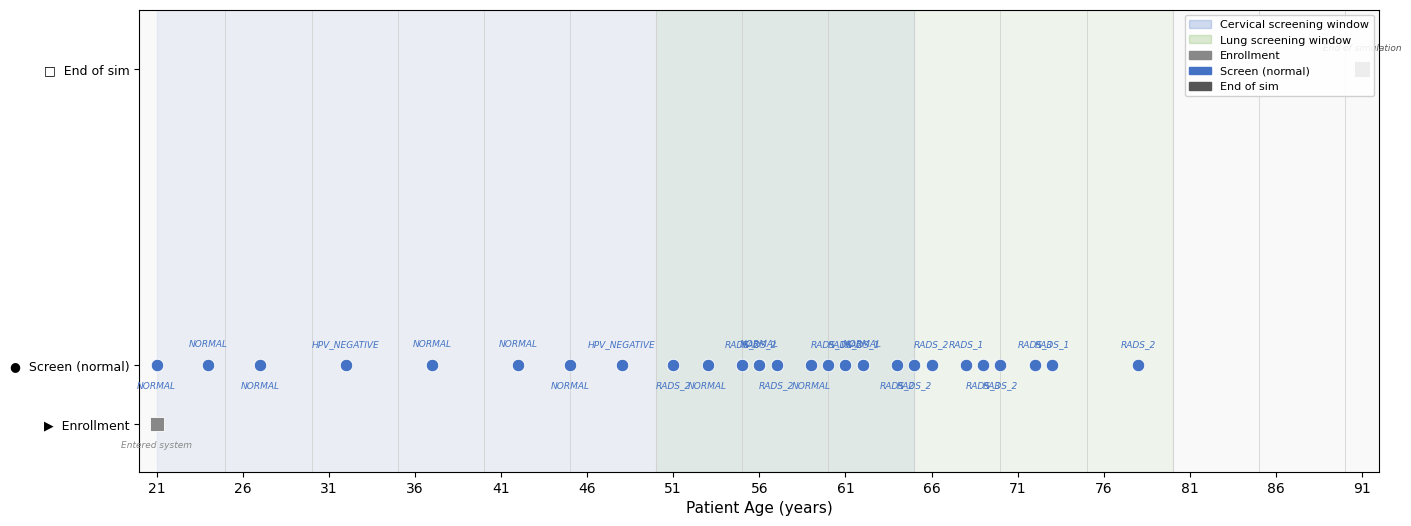

In [15]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Timeline visualisation — 70-year single patient ───────────────────────────
# Each event appears as a marker at (age, y-track).  Clinical categories are
# colour-coded and placed on separate horizontal tracks for readability.
# USPSTF screening windows are shown as shaded background bands.

# ── Colour / y-track map ──────────────────────────────────────────────────────
TRACK = {
    "enrollment":    (0,  "#888888", "▶  Enrollment",    "s",  10),
    "screen_normal": (1,  "#4472C4", "●  Screen (normal)","o",  9),
    "screen_abnormal":(2, "#ED7D31", "●  Screen (abnormal)","o", 11),
    "colposcopy":    (3,  "#FF0000", "▲  Colposcopy",    "^",  11),
    "treatment":     (4,  "#C00000", "★  Treatment",      "*",  14),
    "lung_followup": (5,  "#70AD47", "◆  Lung follow-up", "D",  9),
    "mortality":     (6,  "#000000", "✖  Mortality",      "X",  14),
    "end_of_sim":    (6,  "#555555", "□  End of sim",     "s",  11),
}

fig, ax = plt.subplots(figsize=(16, 6))
ax.set_facecolor("#f9f9f9")

# ── USPSTF shaded windows ─────────────────────────────────────────────────────
cerv_start = max(21, patient.age_at_entry)
cerv_end   = min(65, patient.age_at_entry + 70)
lung_start = 50
lung_end   = 80

if patient.has_cervix and cerv_start < cerv_end:
    ax.axvspan(cerv_start, cerv_end, alpha=0.08, color="#4472C4",
               label="USPSTF cervical window (21–65)")
if patient.smoker:
    ax.axvspan(lung_start, lung_end, alpha=0.08, color="#70AD47",
               label="USPSTF lung window (50–80)")

# ── Plot each timeline event ──────────────────────────────────────────────────
plotted_tracks = set()
for day, age, category, description in timeline:
    if category not in TRACK:
        continue
    y_pos, color, label, marker, size = TRACK[category]
    ax.scatter(age, y_pos, color=color, marker=marker, s=size**2,
               zorder=5, edgecolors="white", linewidths=0.6)
    # Annotate every event with a short label, alternating above/below to avoid overlap
    offset = 0.35 if (age % 6 < 3) else -0.35
    short  = description.split(":")[1].strip() if ":" in description else description.split("—")[0].strip()
    ax.text(age, y_pos + offset, short, fontsize=6.5, ha="center", va="center",
            color=color, rotation=0, fontstyle="italic")
    plotted_tracks.add(category)

# ── Vertical age ticks ────────────────────────────────────────────────────────
for decade_age in range(25, patient.age_at_entry + 71, 5):
    ax.axvline(decade_age, color="#cccccc", linewidth=0.5, zorder=1)

# ── Y-axis labels ─────────────────────────────────────────────────────────────
y_labels = {v[0]: v[2] for k, v in TRACK.items() if k in plotted_tracks}
ax.set_yticks(list(y_labels.keys()))
ax.set_yticklabels(list(y_labels.values()), fontsize=9)
ax.set_ylim(-0.8, 7)

# ── X-axis ────────────────────────────────────────────────────────────────────
ax.set_xlim(patient.age_at_entry - 1, patient.age_at_entry + 71)
ax.set_xlabel("Patient Age (years)", fontsize=11)
ax.set_xticks(range(patient.age_at_entry, patient.age_at_entry + 71, 5))

# ── Legend ────────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color="#4472C4", alpha=0.25, label="Cervical screening window"),
    mpatches.Patch(color="#70AD47", alpha=0.25, label="Lung screening window"),
]
for cat, (_, color, label, _, _) in TRACK.items():
    if cat in plotted_tracks:
        legend_patches.append(mpatches.Patch(color=color, label=label.split("  ")[-1]))
ax.legend(handles=legend_patches, loc="upper right", fontsize=8, framealpha=0.9)

# ── Title ─────────────────────────────────────────────────────────────────────
outcome = f"died age {patient.age}" if patient.exit_reason == "mortality" else f"alive at age {patient.age}"
ax.set_title(
    f"70-Year Patient Trace  |  Entry age {patient.age_at_entry}  |  "
    f"Smoker ({pack_years:.0f} pk-yr entry)  |  {outcome}\n"
    f"Cervical screens: {pt_metrics['n_screened']['cervical']}  ·  "
    f"Lung screens: {pt_metrics['n_screened']['lung']}  ·  "
    f"Colposcopies: {pt_metrics['n_colposcopy']}  ·  "
    f"Treatments: {pt_metrics['n_treated']}",
    fontsize=11, fontweight="bold"
)

plt.tight_layout()
plt.show()


## Full 70-Year Population Simulation

This section runs the **complete simulation**: 15,000 established patients cycling annually over **70 years** (25,550 days).

### What this models
| Component | Detail |
|---|---|
| Stable pool | 15,000 established patients, spread evenly across year 1 during warmup |
| Mortality | Monthly Bernoulli draws with age-specific US life-table rates |
| Replacement | ~4 new entrants/day balance mortality exits |
| Cancer screening | Cervical (USPSTF guidelines) + Lung (LDCT, eligible patients) |
| Follow-up | Colposcopy, LEEP, lung biopsy pathways |
| Persistence | All exited patients written to SQLite (`nyp_70yr.db`) |

### Scale interpretation
- 1 simulated patient = **100 NYC women**  
- 15,000 sim patients ≈ **1.5 million** eligible NYC women  
- All volume metrics can be multiplied by `POPULATION_SCALE_FACTOR = 100` for real-world counts

> ⏱️ Expected runtime: ~15 seconds.

In [ ]:
import sys, time
sys.path.insert(0, '../src')

import config as cfg
from runner import SimulationRunner

print("Starting 70-year population simulation...")
print(f"  Pool size   : {cfg.SIMULATED_POPULATION:,} established patients")
print(f"  Horizon     : {cfg.SIM_YEARS} years ({cfg.SIM_DAYS:,} days)")
print(f"  Scale factor: 1 sim patient = {cfg.POPULATION_SCALE_FACTOR} NYC women")
print()

t0 = time.time()
sim_70yr = SimulationRunner(
    n_days              = cfg.SIM_DAYS,
    seed                = cfg.RANDOM_SEED,
    use_stable_population = True,
    db_path             = "nyp_70yr.db",
    reset_db            = True,
)
metrics_70yr = sim_70yr.run()
elapsed = time.time() - t0

print(f"Simulation complete in {elapsed:.1f}s")
print()
sim_70yr.summary()

In [ ]:
# ── Database summary + revenue analysis ─────────────────────────────────────
print("=== DATABASE SUMMARY ===")
sim_70yr.db_summary()

print()
print("=== REVENUE ANALYSIS ===")
sim_70yr.revenue_summary()

# Keep DB open for longitudinal plots below


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

chk = metrics_70yr["year_checkpoints"]

if not chk:
    print("No year checkpoints recorded — re-run the simulation cell above.")
else:
    years         = [c["year"] for c in chk]
    pool_sizes    = [c["pool_size"] for c in chk]
    cum_cervical  = [c["cum_cervical"] for c in chk]
    cum_lung      = [c["cum_lung"] for c in chk]
    cum_mortality = [c["cum_mortality"] for c in chk]

    # Annual incremental rates (diff of cumulative)
    def annual_increments(cum):
        return [cum[0]] + [cum[i] - cum[i-1] for i in range(1, len(cum))]

    ann_cerv = annual_increments(cum_cervical)
    ann_lung = annual_increments(cum_lung)
    ann_mort = annual_increments(cum_mortality)

    # ── Scale to real-world counts ────────────────────────────────────────
    scale = cfg.POPULATION_SCALE_FACTOR
    pool_real    = [p * scale for p in pool_sizes]
    cerv_real    = [c * scale for c in ann_cerv]
    lung_real    = [c * scale for c in ann_lung]
    mort_real    = [c * scale for c in ann_mort]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("70-Year NYP Women's Health Screening Simulation\n"
                 f"(population × {scale} = real-world NYC estimates)",
                 fontsize=13, fontweight="bold")

    # Panel 1 — Pool stability
    ax = axes[0, 0]
    ax.plot(years, pool_real, color="#2c7bb6", lw=2)
    ax.axhline(cfg.SIMULATED_POPULATION * scale, color="gray", ls="--",
               lw=1, label="Target (1.5M)")
    ax.set_title("Eligible Population Size Over Time")
    ax.set_xlabel("Simulation Year"); ax.set_ylabel("Population (real-world)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.2f}M"))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Panel 2 — Annual cervical screenings
    ax = axes[0, 1]
    ax.bar(years, cerv_real, color="#4dac26", alpha=0.8, width=0.7)
    ax.set_title("Annual Cervical Screenings")
    ax.set_xlabel("Simulation Year"); ax.set_ylabel("Screenings (real-world)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
    ax.grid(axis="y", alpha=0.3)

    # Panel 3 — Annual lung screenings
    ax = axes[1, 0]
    ax.bar(years, lung_real, color="#d7191c", alpha=0.8, width=0.7)
    ax.set_title("Annual Lung LDCT Screenings")
    ax.set_xlabel("Simulation Year"); ax.set_ylabel("Screenings (real-world)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
    ax.grid(axis="y", alpha=0.3)

    # Panel 4 — Annual mortality exits
    ax = axes[1, 1]
    ax.bar(years, mort_real, color="#756bb1", alpha=0.8, width=0.7)
    ax.set_title("Annual Mortality Exits from Pool")
    ax.set_xlabel("Simulation Year"); ax.set_ylabel("Deaths (real-world)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig("70yr_population_simulation.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure saved to 70yr_population_simulation.png")

    # ── Cumulative totals at year 70 ─────────────────────────────────────
    print()
    print("=== CUMULATIVE 70-YEAR TOTALS (real-world scale) ===")
    scale_fmt = lambda n: f"{n * scale:>12,.0f}"
    print(f"  Cervical screens   : {scale_fmt(cum_cervical[-1])}")
    print(f"  Lung screens       : {scale_fmt(cum_lung[-1])}")
    print(f"  Mortality exits    : {scale_fmt(cum_mortality[-1])}")
    print(f"  Colposcopies       : {scale_fmt(metrics_70yr['n_colposcopy'])}")
    print(f"  Treated (LEEP/cone): {scale_fmt(metrics_70yr['n_treated'])}")


## 70-Year Population Simulation — Comprehensive Analytics

The six panels below examine the simulation output from six distinct angles,
each answering a specific question relevant to hospital planning at NYP.

| Panel | Question answered |
|---|---|
| 1 · Patient Journey Cascade | Where do patients drop out of the screening pathway? |
| 2 · Cervical Result Breakdown | What clinical results are we producing, and for whom? |
| 3 · Follow-up & Treatment Cascade | How far do abnormal patients travel along the care pathway? |
| 4 · Annual Revenue Trend | How does screening activity translate to procedure revenue over time? |
| 5 · Lung LDCT Funnel | What is the yield of the lung cancer screening pathway? |
| 6 · Population Dynamics & Overflow | Is the open-loop model stable? Where are the capacity bottlenecks? |

> All counts are **simulation-scale** (1 sim patient = 100 NYC women).  
> Multiply by `POPULATION_SCALE_FACTOR = 100` for real-world estimates.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import config as cfg

m   = metrics_70yr   # produced by the run cell above
chk = m["year_checkpoints"]

# ── Build cascade values ──────────────────────────────────────────────────────
total_seen    = m["n_patients"]
eligible      = m["n_eligible_any"]
cerv_screened = m["n_screened"]["cervical"]
lung_screened = m["n_screened"]["lung"]

# Abnormal cervical results (everything except NORMAL and HPV_NEGATIVE)
abnormal_cerv = sum(
    v for k, v in m["cervical_results"].items()
    if k not in ("NORMAL", "HPV_NEGATIVE")
)
hpv_pos       = m["cervical_results"].get("HPV_POSITIVE", 0)
total_abnormal = abnormal_cerv + hpv_pos

colposcopies  = m["n_colposcopy"]
cin2_plus     = (m["colposcopy_results"].get("CIN2", 0)
               + m["colposcopy_results"].get("CIN3", 0))
treated       = m["n_treated"]
ltfu_total    = m["n_ltfu"]

# ── Compute LTFU gaps between steps ──────────────────────────────────────────
ltfu_post_abnormal   = m["ltfu_post_abnormal"]
ltfu_post_colposcopy = m["ltfu_post_colposcopy"]

# ── Chart ─────────────────────────────────────────────────────────────────────
labels = [
    "Patients seen by provider",
    "Eligible for ≥1 screening",
    "Cervical screens completed",
    "Lung LDCT screens completed",
    "Abnormal cervical result",
    "Referred to colposcopy",
    "CIN2+ detected",
    "Treatment completed (LEEP/cone)",
]
values = [
    total_seen, eligible, cerv_screened, lung_screened,
    total_abnormal, colposcopies, cin2_plus, treated,
]

# Colour: teal for screening steps, amber for clinical cascade, green for treatment
colors = ["#2c7bb6","#2c7bb6","#4dac26","#d7191c",
          "#fdae61","#f46d43","#d73027","#1a9641"]

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = np.arange(len(labels))
bars  = ax.barh(y_pos, values, color=colors, edgecolor="white", height=0.65)

# Annotate each bar
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + total_seen * 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", ha="left", fontsize=9)

# LTFU arrows between relevant steps
def ltfu_arrow(ax, from_y, to_y, loss, x_offset):
    mid_y = (from_y + to_y) / 2
    ax.annotate(f"LTFU: {loss:,}",
                xy=(x_offset, to_y + 0.32), xytext=(x_offset, from_y - 0.32),
                arrowprops=dict(arrowstyle="-|>", color="#888", lw=1.2),
                color="#888", fontsize=8, ha="center", va="center")

ltfu_arrow(ax, 4, 5, ltfu_post_abnormal, total_seen * 0.45)
ltfu_arrow(ax, 5, 7, ltfu_post_colposcopy, total_seen * 0.30)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Patient count (simulation scale)", fontsize=10)
ax.set_title("Panel 1 — Patient Journey Cascade (70-Year Simulation)\n"
             "Full pathway from provider visit to cancer treatment",
             fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)

legend_patches = [
    mpatches.Patch(color="#2c7bb6", label="Provider access"),
    mpatches.Patch(color="#4dac26", label="Cervical screening"),
    mpatches.Patch(color="#d7191c", label="Lung screening"),
    mpatches.Patch(color="#fdae61", label="Abnormal / follow-up"),
    mpatches.Patch(color="#1a9641", label="Treatment completed"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("panel1_patient_cascade.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Cascade saved.  LTFU post-abnormal: {ltfu_post_abnormal:,} | post-colposcopy: {ltfu_post_colposcopy:,}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 2: Cervical result distribution by age stratum ─────────────────────
ax = axes[0]
strata      = ["young", "middle"]
result_cats = ["NORMAL", "HPV_NEGATIVE", "HPV_POSITIVE", "ASCUS", "LSIL", "ASC-H", "HSIL"]
result_cols = ["#4dac26","#a6d96a","#fdae61","#fee08b","#f46d43","#d73027","#a50026"]

stratum_data = {}
for s in strata:
    sd = m["cervical_by_age_stratum"].get(s, {})
    total = sum(sd.values()) or 1
    stratum_data[s] = {cat: sd.get(cat, 0) / total * 100 for cat in result_cats}

x    = np.arange(len(strata))
w    = 0.12
offset = np.linspace(-(len(result_cats)-1)/2*w, (len(result_cats)-1)/2*w, len(result_cats))
for i, (cat, col) in enumerate(zip(result_cats, result_cols)):
    vals = [stratum_data[s][cat] for s in strata]
    ax.bar(x + offset[i], vals, width=w, color=col, label=cat)

ax.set_xticks(x)
ax.set_xticklabels(["Age 21–29\n(cytology only)", "Age 30–65\n(cytology / HPV-alone)"], fontsize=10)
ax.set_ylabel("% of screens in stratum", fontsize=10)
ax.set_title("Panel 2 — Cervical Result Distribution\nby Age Stratum", fontsize=11, fontweight="bold")
ax.legend(fontsize=8, loc="upper right", ncol=2)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)

# ── Panel 3: Colposcopy CIN grade → treatment cascade ───────────────────────
ax = axes[1]
cin_labels  = ["NORMAL", "CIN1", "CIN2", "CIN3"]
cin_colors  = ["#4dac26","#fee08b","#f46d43","#a50026"]
cin_counts  = [m["colposcopy_results"].get(g, 0) for g in cin_labels]

treatment_breakdown = {
    "LEEP":         m["n_treatment"].get("leep", 0),
    "Surveillance": m["n_treatment"].get("surveillance", 0),
}

# Left: CIN grade donut
wedges, texts, autotexts = ax.pie(
    cin_counts, labels=cin_labels, colors=cin_colors,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    startangle=90, wedgeprops=dict(width=0.55),
    textprops=dict(fontsize=9),
)
for at in autotexts: at.set_fontsize(8)

centre_text = f"n={sum(cin_counts):,}\ncolposcopies"
ax.text(0, 0, centre_text, ha="center", va="center", fontsize=9, fontweight="bold")
ax.set_title("Panel 3 — Colposcopy Results\n(CIN grade distribution)", fontsize=11, fontweight="bold")

# Inset bar for treatment types
inset = ax.inset_axes([0.65, 0.05, 0.35, 0.35])
inset.bar(treatment_breakdown.keys(), treatment_breakdown.values(),
          color=["#d73027","#4dac26"], edgecolor="white")
inset.set_title("Treatment\ntype", fontsize=7)
inset.tick_params(labelsize=7)
inset.set_ylabel("count", fontsize=7)
for spine in inset.spines.values(): spine.set_visible(False)

plt.tight_layout()
plt.savefig("panel2_3_clinical.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Compute annual increments from checkpoints ────────────────────────────────
def increments(key):
    vals = [c[key] for c in chk]
    return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

years     = [c["year"] for c in chk]
ann_cerv  = increments("cum_cervical")
ann_lung  = increments("cum_lung")
ann_colp  = increments("cum_colposcopy")
ann_leep  = increments("cum_leep")
ann_lbx   = increments("cum_lung_biopsy")
ann_ltx   = increments("cum_lung_treatment")

# Revenue per procedure (from config)
rev = cfg.PROCEDURE_REVENUE
# Cervical: approx 60% cytology, 40% HPV-alone
ann_rev_cerv  = [c * (0.6*rev["cytology"] + 0.4*rev["hpv_alone"]) for c in ann_cerv]
ann_rev_colp  = [c * rev["colposcopy"]      for c in ann_colp]
ann_rev_leep  = [c * rev["leep"]            for c in ann_leep]
ann_rev_lung  = [c * rev["ldct"]            for c in ann_lung]
ann_rev_lbx   = [c * rev["lung_biopsy"]     for c in ann_lbx]
ann_rev_ltx   = [c * rev["lung_treatment"]  for c in ann_ltx]

# LTFU lost revenue: abnormal patients who never got colposcopy
# estimate: each LTFU post-abnormal = foregone colposcopy + avg downstream
ltfu_ann     = increments("cum_ltfu")
ltfu_rev_lost = [l * (rev["colposcopy"] * 0.6 + rev["leep"] * 0.3) for l in ltfu_ann]

bar_data = {
    "Cervical screening":  ann_rev_cerv,
    "Colposcopy":          ann_rev_colp,
    "LEEP / cone":         ann_rev_leep,
    "Lung LDCT":           ann_rev_lung,
    "Lung biopsy":         ann_rev_lbx,
    "Lung treatment":      ann_rev_ltx,
}
bar_colors = ["#4dac26","#f46d43","#d73027","#2c7bb6","#5e4fa2","#3288bd"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios":[3,1]})

# Stacked bar — annual realized revenue
bottom = np.zeros(len(years))
for (label, vals), col in zip(bar_data.items(), bar_colors):
    arr = np.array(vals)
    ax1.bar(years, arr, bottom=bottom, color=col, label=label, width=0.8, alpha=0.9)
    bottom += arr

ax1.set_title("Panel 4 — Annual Realized Procedure Revenue (70-Year Simulation)",
              fontsize=12, fontweight="bold")
ax1.set_ylabel("Revenue (USD, simulation scale)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"\${x/1e6:.1f}M"))
ax1.legend(loc="upper right", fontsize=9, ncol=3)
ax1.grid(axis="y", alpha=0.3)
ax1.spines[["top","right"]].set_visible(False)
ax1.set_xlim(0.5, max(years) + 0.5)

# Line — LTFU lost revenue
ax2.bar(years, ltfu_rev_lost, color="#888", alpha=0.6, label="Revenue lost to LTFU", width=0.8)
ax2.set_ylabel("Lost revenue (USD)")
ax2.set_xlabel("Simulation Year")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"\${x/1e3:.0f}K"))
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)
ax2.spines[["top","right"]].set_visible(False)
ax2.set_xlim(0.5, max(years) + 0.5)

plt.tight_layout()
plt.savefig("panel4_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

total_rev = sum(sum(v) for v in bar_data.values())
total_lost = sum(ltfu_rev_lost)
print(f"Total realized revenue (70yr, sim scale): \${total_rev:>12,.0f}")
print(f"Total LTFU lost revenue (estimated)     : \${total_lost:>12,.0f}")
print(f"Recovery rate                            : {total_rev/(total_rev+total_lost)*100:.1f}%")

In [ ]:
# ── Panel 5: Lung LDCT pathway funnel ────────────────────────────────────────
steps = [
    ("Lung-eligible patients",     m["lung_eligible"]),
    ("Referral placed",            m["lung_referral_placed"]),
    ("LDCT scheduled",             m["lung_ldct_scheduled"]),
    ("LDCT completed",             m["lung_ldct_completed"]),
    ("Result communicated",        m["lung_result_communicated"]),
    ("RADS 4A/4B — biopsy referral", m["lung_biopsy_referral"]),
    ("Biopsy completed",           m["lung_biopsy_completed"]),
    ("Malignancy confirmed",       m["lung_malignancy_confirmed"]),
    ("Treatment given",            m["lung_treatment_given"]),
]
step_labels = [s[0] for s in steps]
step_vals   = [s[1] for s in steps]

# RADS distribution inset
rads_cats  = ["RADS_0","RADS_1","RADS_2","RADS_3","RADS_4A","RADS_4B_4X"]
rads_cols  = ["#ccc","#4dac26","#a6d96a","#fdae61","#f46d43","#d73027"]
rads_counts = [m["lung_rads_distribution"].get(r, 0) for r in rads_cats]

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 5.5),
                                         gridspec_kw={"width_ratios":[2,1]})

# Horizontal funnel (left)
norm_vals = [v / step_vals[0] if step_vals[0] > 0 else 0 for v in step_vals]
colors_f  = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(steps)))
y_pos     = np.arange(len(steps))
bars = ax_left.barh(y_pos, step_vals, color=colors_f, edgecolor="white", height=0.65)
for bar, val, pct in zip(bars, step_vals, norm_vals):
    ax_left.text(bar.get_width() + step_vals[0]*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f"{val:,}  ({pct:.1%})", va="center", fontsize=9)
ax_left.set_yticks(y_pos)
ax_left.set_yticklabels(step_labels, fontsize=9)
ax_left.set_xlabel("Patient count (simulation scale)", fontsize=10)
ax_left.set_title("Panel 5 — Lung LDCT Screening Pathway\n(70-year cumulative)", fontsize=11, fontweight="bold")
ax_left.invert_yaxis()
ax_left.grid(axis="x", alpha=0.3)
ax_left.spines[["top","right"]].set_visible(False)

# RADS distribution (right)
wedges, texts, autotexts = ax_right.pie(
    rads_counts, labels=rads_cats, colors=rads_cols,
    autopct=lambda p: f"{p:.1f}%" if p > 1 else "",
    startangle=90, wedgeprops=dict(width=0.55),
    textprops=dict(fontsize=9),
)
for at in autotexts: at.set_fontsize(8)
total_rads = sum(rads_counts)
ax_right.text(0, 0, f"n={total_rads:,}\nLDCT results",
              ha="center", va="center", fontsize=9, fontweight="bold")
ax_right.set_title("Lung-RADS\nDistribution", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("panel5_lung_funnel.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Lung malignancy detection rate: {step_vals[-2]}/{step_vals[0]} = {step_vals[-2]/step_vals[0]*100:.2f}% of eligible patients")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 6a: Annual new entrants vs mortality vs pool size ─────────────────────────
ax = axes[0]
ann_mort      = increments("cum_mortality")
ann_patients  = increments("cum_n_patients")

ax.bar(years, ann_mort, color="#a50026", alpha=0.8, label="Mortality exits", width=0.8)
# New entrants ≈ annual provider contacts minus established reschedules (approx)
ax2_twin = ax.twinx()
ax2_twin.plot(years, [c["pool_size"] for c in chk], "k--", lw=1.5, label="Pool size")
ax2_twin.set_ylabel("Pool size", fontsize=9)
ax2_twin.set_ylim(cfg.SIMULATED_POPULATION * 0.8, cfg.SIMULATED_POPULATION * 1.2)
ax2_twin.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.set_title("6a — Annual Mortality &\nPool Stability", fontsize=10, fontweight="bold")
ax.set_xlabel("Simulation Year"); ax.set_ylabel("Count", fontsize=9)
ax.legend(loc="upper left", fontsize=8)
ax2_twin.legend(loc="upper right", fontsize=8)
ax.grid(axis="y", alpha=0.3)

# ── 6b: Annual screening throughput ──────────────────────────────────────────
ax = axes[1]
ax.bar(years, ann_cerv, color="#4dac26", alpha=0.9, label="Cervical screens", width=0.8)
ax.bar(years, ann_lung, bottom=ann_cerv, color="#2c7bb6", alpha=0.9, label="Lung LDCT", width=0.8)
ax.set_title("6b — Annual Screening\nThroughput", fontsize=10, fontweight="bold")
ax.set_xlabel("Simulation Year"); ax.set_ylabel("Screens completed", fontsize=9)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
# Reference line: expected cervical rate (eligible pop × 1/3 for 3-yr interval)
expected_cerv_yr = cfg.SIMULATED_POPULATION * 0.7 * (1/3)
ax.axhline(expected_cerv_yr, color="#4dac26", ls="--", lw=1, alpha=0.5,
           label=f"Expected ~{expected_cerv_yr:.0f}/yr")
ax.legend(fontsize=8)

# ── 6c: Provider overflow ─────────────────────────────────────────────────────
ax = axes[2]
overflow = m.get("overflow", {})
providers = ["pcp","gynecologist","specialist","er"]
prov_labels = ["PCP","Gynecologist","Specialist","ER"]
ov_counts   = [overflow.get(p, 0) for p in providers]
ov_colors   = ["#2c7bb6","#4dac26","#fdae61","#d73027"]
bars = ax.bar(prov_labels, ov_counts, color=ov_colors, edgecolor="white")
for bar, val in zip(bars, ov_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(ov_counts)*0.01,
            f"{val:,}", ha="center", fontsize=9)
ax.set_title("6c — Provider Overflow\n(patients deferred, 70-year total)", fontsize=10, fontweight="bold")
ax.set_ylabel("Overflow patient-days", fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Panel 6 — Population Dynamics & Operational Capacity", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("panel6_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()
print("All 6 panels saved.")
# Close DB after all visualizations
sim_70yr.close_db()
print("Database connection closed.")